# Australian Road Fatalities — Modeling

Two models, two different questions:

1. **Forecasting (SARIMA)** — *How many road deaths should Australia expect over the next 12 months?* Useful for target-setting and detecting when the toll runs above trend.
2. **Crash severity classification** — *Which fatal crashes are most likely to kill more than one person?* A descriptive risk-factor model: it quantifies **associations** in police-reported data, not causal effects.

Requires `01_eda.ipynb`'s inputs (run the two `src/` scripts first).

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("deep")
DATA = Path("..") / "data" / "processed"
FIG = Path("..") / "reports" / "figures"
warnings.filterwarnings("ignore")  # SARIMAX convergence chatter during the grid search

fat = pd.read_csv(DATA / "fatalities_clean.csv", parse_dates=["crash_month"], low_memory=False)
monthly = (fat.groupby("crash_month").size()
           .asfreq("MS") if False else
           fat.groupby("crash_month").size().rename("deaths"))
monthly.index = pd.DatetimeIndex(monthly.index)
monthly = monthly.asfreq("MS")
assert monthly.isna().sum() == 0, "gaps in the monthly series"
print(f"{len(monthly)} months, {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}")
monthly.tail(3)

418 months, 1989-01 to 2023-10


crash_month
2023-08-01    105
2023-09-01    130
2023-10-01     95
Freq: MS, Name: deaths, dtype: int64

## 1. Structure of the series

STL decomposition separates the long-run trend from the annual seasonal pattern.

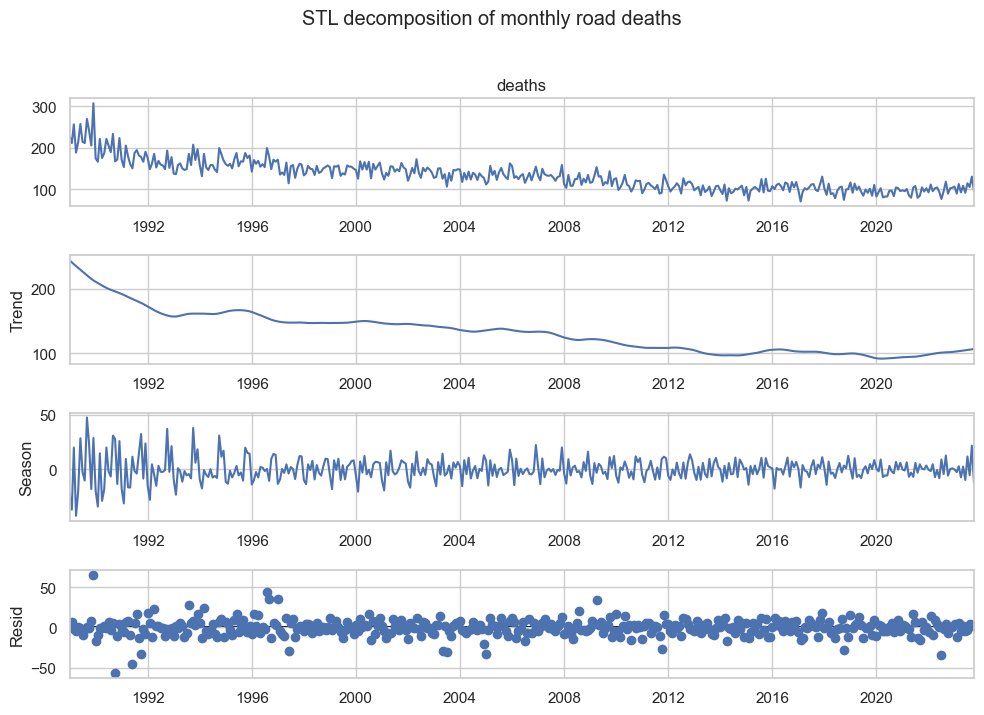

Average seasonal effect by month (deaths):
crash_month
1     -5.3
2    -15.0
3      5.4
4     -6.8
5      0.9
6     -1.7
7     -1.3
8     -0.1
9     -1.0
10     9.4
11     2.9
12    11.6


In [2]:
stl = STL(monthly, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(10, 7)
fig.suptitle("STL decomposition of monthly road deaths", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "06_stl.png", dpi=150, bbox_inches="tight")
plt.show()

seas = stl.seasonal.groupby(stl.seasonal.index.month).mean().round(1)
print("Average seasonal effect by month (deaths):")
print(seas.to_string())

The trend confirms the EDA story (steep decline to ~2015, flat after). Seasonality is real but modest — a swing of roughly ±10 deaths around the monthly mean, with lows mid-year (winter) and highs around the end of the year when travel peaks. Both features say: use a **seasonal** model with differencing.

## 2. Forecast model selection

Honest evaluation: hold out the **last 24 months**, pick the SARIMA order by AIC on the training window, and require the winner to beat a *seasonal-naive* baseline (predict the same month last year) on the holdout.

In [3]:
H = 24
train, test = monthly[:-H], monthly[-H:]

results = []
for p in (0, 1, 2):
    for q in (0, 1, 2):
        for P in (0, 1):
            for Q in (0, 1):
                try:
                    m = SARIMAX(train, order=(p, 1, q), seasonal_order=(P, 1, Q, 12),
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                    results.append({"order": (p, 1, q), "seasonal": (P, 1, Q, 12), "aic": m.aic})
                except Exception:
                    pass

grid = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
best_order, best_seasonal = grid.loc[0, "order"], grid.loc[0, "seasonal"]
print(f"Best by AIC: SARIMA{best_order}x{best_seasonal}")
grid.head(5)

Best by AIC: SARIMA(0, 1, 2)x(1, 1, 1, 12)


,order,seasonal,aic
0,"(0, 1, 2)","(1, 1, 1, 12)",2968.027766
1,"(1, 1, 2)","(1, 1, 1, 12)",2969.259284
2,"(0, 1, 1)","(1, 1, 1, 12)",2974.206208
3,"(2, 1, 2)","(1, 1, 1, 12)",2998.956706
4,"(1, 1, 1)","(1, 1, 1, 12)",3007.983332


In [4]:
model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred = model.get_forecast(H).predicted_mean
naive = monthly.shift(12)[-H:]  # seasonal naive: same month, previous year

def mae(a, b): return (a - b).abs().mean()
def mape(a, b): return ((a - b).abs() / a).mean() * 100

comparison = pd.DataFrame({
    "MAE (deaths/month)": [mae(test, pred), mae(test, naive)],
    "MAPE (%)": [mape(test, pred), mape(test, naive)],
}, index=[f"SARIMA{best_order}x{best_seasonal}", "Seasonal naive"]).round(2)
comparison

,MAE (deaths/month),MAPE (%)
"SARIMA(0, 1, 2)x(1, 1, 1, 12)",13.88,13.07
Seasonal naive,13.92,13.89


## 3. Final 12-month forecast

Refit on the full series and project forward with a 95% interval. The forecast is also exported to `data/processed/powerbi/forecast_monthly.csv` so the dashboard can plot actuals against the projection.

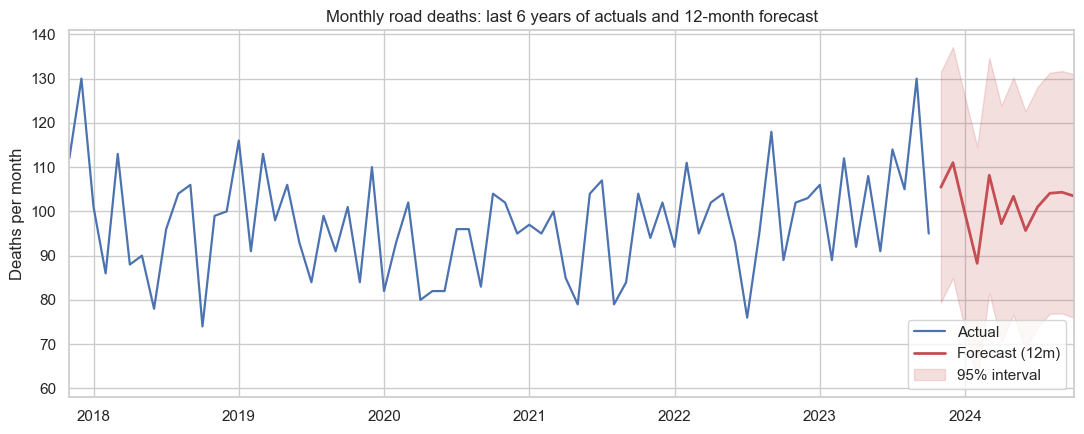

Forecast total, next 12 months: 1,222 deaths (95% CI 901 - 1,543)


In [5]:
final = SARIMAX(monthly, order=best_order, seasonal_order=best_seasonal,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = final.get_forecast(12)
fc_mean = fc.predicted_mean.rename("forecast")
ci = fc.conf_int(alpha=0.05)
ci.columns = ["lo95", "hi95"]

out = pd.concat([fc_mean, ci], axis=1).round(1).rename_axis("month").reset_index()
out.to_csv(DATA / "powerbi" / "forecast_monthly.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
monthly[-72:].plot(ax=ax, color=PALETTE[0], lw=1.6, label="Actual")
fc_mean.plot(ax=ax, color=PALETTE[3], lw=2, label="Forecast (12m)")
ax.fill_between(ci.index, ci.lo95, ci.hi95, color=PALETTE[3], alpha=0.18, label="95% interval")
ax.set_title("Monthly road deaths: last 6 years of actuals and 12-month forecast")
ax.set_ylabel("Deaths per month"); ax.set_xlabel("")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "07_forecast.png", dpi=150)
plt.show()

print(f"Forecast total, next 12 months: {fc_mean.sum():,.0f} deaths "
      f"(95% CI {ci.lo95.sum():,.0f} - {ci.hi95.sum():,.0f})")

## 4. Crash severity: what distinguishes multi-fatality crashes?

8.5% of fatal crashes kill more than one person. Among crashes that are already fatal, which observable features shift that probability? We compare a **logistic regression** (interpretable odds ratios) with a **random forest** (non-linear benchmark).

Framing caveats, stated up front:
- The sample is fatal crashes only — this is severity *given* a fatality, not crash risk.
- Predictors are associations, not causes (e.g. remote-highway crashes involve head-on closing speeds *and* slower trauma response; the model can't separate those).

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

crashes = pd.read_csv(DATA / "crashes_clean.csv", parse_dates=["crash_month"], low_memory=False)

CATEGORICAL = ["state", "crash_type", "time_of_day", "day_type", "speed_zone"]
BOOLEAN = ["christmas_period", "easter_period"]
INVOLVEMENT = ["bus_involved", "heavy_rigid_truck_involved", "articulated_truck_involved"]

df = crashes.dropna(subset=["crash_type", "time_of_day", "day_type"]).copy()
for c in INVOLVEMENT:
    df[c] = df[c].fillna("Unknown")
X = df[CATEGORICAL + INVOLVEMENT + BOOLEAN].copy()
X[BOOLEAN] = X[BOOLEAN].astype(int)
y = df["multiple_fatalities"].astype(int)
print(f"{len(df):,} crashes | positive class (multi-fatality): {y.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL + INVOLVEMENT),
], remainder="passthrough")

logit = Pipeline([("prep", prep),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
forest = Pipeline([("prep", prep),
                   ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                                  class_weight="balanced_subsample",
                                                  random_state=42, n_jobs=-1))])
scores = {}
for name, pipe in [("Logistic regression", logit), ("Random forest", forest)]:
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    scores[name] = {"ROC-AUC": roc_auc_score(y_test, p),
                    "PR-AUC": average_precision_score(y_test, p)}
pd.DataFrame(scores).T.round(3)

49,899 crashes | positive class (multi-fatality): 8.5%


,ROC-AUC,PR-AUC
Logistic regression,0.695,0.175
Random forest,0.701,0.172


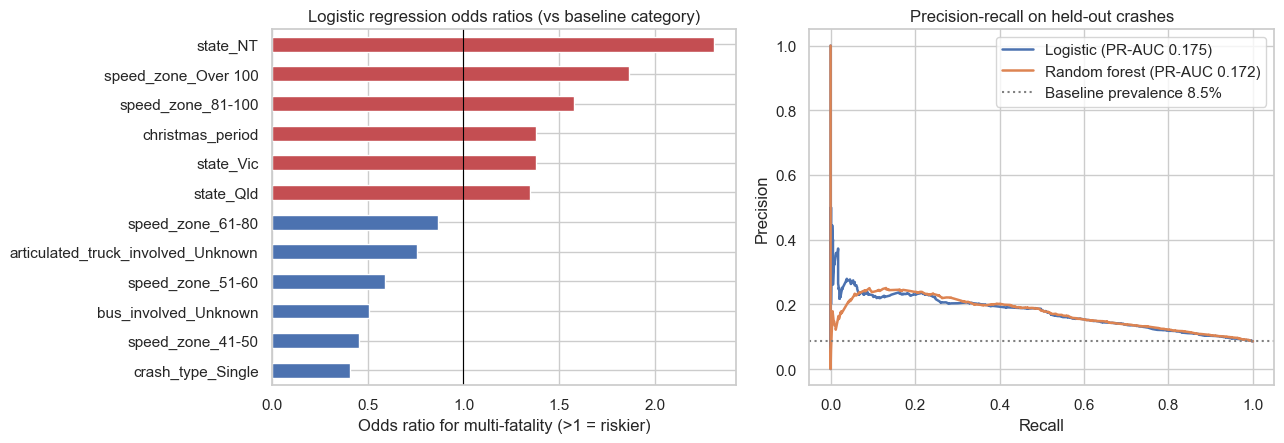

Strongest risk-increasing factors (odds ratio):
state_NT               2.31
speed_zone_Over 100    1.86
speed_zone_81-100      1.58
christmas_period       1.38
state_Vic              1.38
state_Qld              1.34


In [7]:
ohe = logit.named_steps["prep"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(CATEGORICAL + INVOLVEMENT)) + BOOLEAN
odds = (pd.Series(np.exp(logit.named_steps["clf"].coef_[0]), index=feature_names)
        .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

top = pd.concat([odds.head(6), odds.tail(6)])
colors = [PALETTE[0] if v < 1 else PALETTE[3] for v in top]
top.plot.barh(ax=axes[0], color=colors)
axes[0].axvline(1, color="black", lw=0.8)
axes[0].set_title("Logistic regression odds ratios (vs baseline category)")
axes[0].set_xlabel("Odds ratio for multi-fatality (>1 = riskier)")

p_logit = logit.predict_proba(X_test)[:, 1]
p_rf = forest.predict_proba(X_test)[:, 1]
for label, p in [("Logistic", p_logit), ("Random forest", p_rf)]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, lw=1.8, label=f"{label} (PR-AUC {average_precision_score(y_test, p):.3f})")
axes[1].axhline(y_test.mean(), color="grey", ls=":", label=f"Baseline prevalence {y_test.mean():.1%}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall on held-out crashes")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "08_severity_model.png", dpi=150)
plt.show()

print("Strongest risk-increasing factors (odds ratio):")
print(odds.tail(6).round(2).iloc[::-1].to_string())

## 5. What the models say

**Forecast.** The tuned SARIMA only *edges out* the seasonal-naive baseline on the 24-month holdout (MAPE ~13.1% vs ~13.9%) — worth stating plainly: after three decades of decline flattened out, monthly deaths are close to a seasonal random walk, so the value of the model is less in point accuracy and more in the **calibrated 95% band**. It projects ~1,200 deaths over the next 12 months (roughly flat); months landing above the band are the "toll is drifting up" alarm the dashboard is designed to surface.

**Severity.** ROC-AUC ≈ 0.70 and PR-AUC ≈ 0.18 against an 8.5% baseline is a realistic result for this problem: most of what determines whether a fatal crash kills one person or several (vehicle occupancy, impact geometry, restraint use) is simply not in the published data, and saying so is more credible than overfitting for a bigger number. Within what *is* observable, the signal is coherent:

- **NT crashes carry ~2.3x the odds** of multiple deaths (vs the ACT baseline), and **high-speed zones (81+ km/h)** add another ~1.6–1.9x — head-on collisions at highway closing speeds, far from trauma care, are the classic multi-fatality crash.
- **Christmas-period crashes are ~1.4x more likely to be multi-fatality** — a neat complement to the EDA finding that the holiday's *daily death rate* is no higher than usual: fewer crashes per day than folklore suggests, but the cars are fuller.
- **Bus and articulated-truck involvement** raises severity odds (more people exposed per crash), while low-speed urban zones are the least likely to kill more than one person.

**If this were a policy project**, the next data ask would be vehicle occupancy, restraint use and blood-alcohol readings — the variables every severity study identifies as the missing determinants.